# Audio Processing - Automatic Music Transcription (AMT)

Aim: Design a polyphonic, single-instrument, note-level AMT pipeline for converting audio recording (.wav) into the MIDI dict format which can be passed into compare_performance_ED() in compare_MIDI.py.
- audio → pitch + onset + offset
- Although only one instrument is present in one recording, piano performances are inherently polyphonic because multiple notes may sound simultaneously (e.g., block chords or overlapping sustained notes). 
 
General sturcture of AMT pipeline:
- Step 1: read in the .wav audio file
- Step 2: preprocessing, prepare audio for the model
    - Time-frequency representation (Spectrogram) - Fourier Analysis of Signals: STFT, CQT
    - Pitch/Note/Onset estimation (Multi-Pitch Estimation (MPE) for Polyphonic)
- Step 3: AMT model (CNN/LSTM/Transformer)
- Step 4: postprocessing, convert the model output to the MIDI dict format which can be passed into compare_performance_ED()

---

consider using Basic Pitch: it is a Python library for AMT, using lightweight neural network developed by Spotify's Audio Intelligence Lab.: https://arxiv.org/pdf/2203.09893

https://github.com/spotify/basic-pitch

@inproceedings{2022_BittnerBRME_LightweightNoteTranscription_ICASSP,
  author= {Bittner, Rachel M. and Bosch, Juan Jos\'e and Rubinstein, David and Meseguer-Brocal, Gabriel and Ewert, Sebastian},
  title= {A Lightweight Instrument-Agnostic Model for Polyphonic Note Transcription and Multipitch Estimation},
  booktitle= {Proceedings of the IEEE International Conference on Acoustics, Speech, and Signal Processing (ICASSP)},
  address= {Singapore},
  year= 2022,
}

---

extend the existing code by proper post-processing steps

may find https://yonghyunk1m.github.io/PianoVAM/ useful, need to investigate this dataset more carefully. The dataset
was recorded using a Disklavier piano, capturing audio and MIDI from amateur pianists during their daily practice sessions. This dataset includes videos, audio, MIDI, hand landmarks, fingering labels, and rich metadata, but the Github repo is still under construction.
- MIDI captured by Disklavier can be used as reference? processing audio with basic pitch to get response MIDI? https://huggingface.co/datasets/PianoVAM/PianoVAM_v1 

it may be helpful for improving the pretrained model, i.e. feedback-oriented post-processing:
- fit the pre-trained model on the PianoVAM dataset, evaluate: AMT metrics (precision、recall、F1), Feedback analysis (Pitch feedback accuracy, Missing-note feedback precision, Extra-note feedback precision, Chord feedback accuracy, Timing feedback accuracy, Duration feedback accuracy...)


@inproceedings{kim2025pianovam,
  title={PianoVAM: A Multimodal Piano Performance Dataset},
  author={Yonghyun Kim and Junhyung Park and Joonhyung Bae and Taegyun Kwon and Kirak Kim and Alexander Lerch and Juhan Nam},
  booktitle={Proceedings of the 26th International Society for Music Information Retrieval Conference (ISMIR)},
  year={2025},
  address={Daejeon, South Korea}
}

---

In this notebook:

1. The first goal is to make the full workflow run correctly on one selected sample (the simplest case).
    - Use the pretrained Basic Pitch model to transcribe the audio.
    - Convert the predicted MIDI into the dictionary format used by `compare_performance_ED()`.
    - Compare the prediction with the PianoVAM performance MIDI.
2. Then apply to all recordings for quantitative evaluation. 
    - Visualise and evaluate the transcription.
    - Inspect how AMT errors propagate into the existing feedback pipeline, find out how to improve the results (maybe implement my own postprocessing)

For the Basic Pitch:
- The input to Basic Pitch is the PianoVAM `.wav` audio recording.
- Basic Pitch returns:
    - `model_output`: raw model inference output (frame-level onset, note and pitch-contour activations);
    - `predicted_midi`: transcribed MIDI data derived from the model_output (a `pretty_midi.PrettyMIDI` object produced by Basic Pitch post-processing);
    - `note_events`: a list of note events derived from the model_output (decoded note-level events containing onset, offset, pitch, amplitude and optional pitch-bend information).

For this baseline, the official pretrained model and its built-in preprocessing and post-processing are used without training or fine-tuning.

The ground truth for AMT evaluation is the PianoVAM performance MIDI recorded by the Disklavier (digital piano) for the same recording, not a musical score MIDI.

## Download PianoVAM dataset (MIDI and audio only)

Download and inspect the dataset first, only download necessary files, video and hand-skeleton files are excluded because they are not needed for the transcription task.

In [1]:
from pathlib import Path
from huggingface_hub import snapshot_download

PIANOVAM_ROOT = Path("data/PianoVAM_v1")

def download_pianovam(local_dir):
    """
    Download parts of PianoVAM needed for audio transcription and
    downstream feedback evaluation.
    """
    local_dir = Path(local_dir)
    snapshot_download(
        repo_id="PianoVAM/PianoVAM_v1",
        repo_type="dataset",
        local_dir=local_dir,
        allow_patterns=[
            "Audio/*",
            "MIDI/*",
            "TSV/*",
            "metadata.json"
        ],
    )
    return local_dir

PIANOVAM_ROOT = download_pianovam(PIANOVAM_ROOT)

audio_files = sorted((PIANOVAM_ROOT / "Audio").glob("*.wav"))
midi_files = sorted((PIANOVAM_ROOT / "MIDI").glob("*.mid"))
tsv_files = sorted((PIANOVAM_ROOT / "TSV").glob("*.tsv"))

print(f"PianoVAM root: {PIANOVAM_ROOT}")
print(f"Audio files: {len(audio_files)}")
print(f"MIDI files: {len(midi_files)}")
print(f"TSV files: {len(tsv_files)}")
print(f"Metadata exists: {(PIANOVAM_ROOT / 'metadata.json').exists()}")

if len(audio_files) == 0:
    raise FileNotFoundError("No audio files found.")

if len(midi_files) == 0:
    raise FileNotFoundError("No MIDI files found.")

if len(tsv_files) == 0:
    raise FileNotFoundError("No TSV files found.")

if not (PIANOVAM_ROOT / "metadata.json").exists():
    raise FileNotFoundError("metadata.json was not downloaded.")

/Users/jz7125/compareMusic/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 322 files: 100%|██████████| 322/322 [00:00<00:00, 731.22it/s]

PianoVAM root: data/PianoVAM_v1
Audio files: 107
MIDI files: 107
TSV files: 107
Metadata exists: True


inspect the metadata first

In [2]:
import json
import pandas as pd

METADATA_PATH = PIANOVAM_ROOT / "metadata.json"

with open(METADATA_PATH, "r") as file:
    metadata = json.load(file)

metadata_df = (
    pd.DataFrame.from_dict(
        metadata,
        orient="index"
    )
    .reset_index(names="sample_id")
)

print(metadata_df.shape)

metadata_df.head()

(107, 22)


,sample_id,record_time,split,composer,piece,performance_method,performance_type,duration,P1_name,P1_gender,...,P1_musicmajor,P2_name,P2_gender,P2_age,P2_skill,P2_musicmajor,Point_LT,Point_RT,Point_RB,Point_LB
0,0,2024-02-14_19-10-09,train,E. Grieg,Piano Concerto,Solo,DailyPractice,0 days 00:12:25.493.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"121, 355","1839, 345","1839, 558","120, 564"
1,1,2024-02-14_19-44-26,train,N. Kapustin,Concert Etude No.6,Solo,DailyPractice,0 days 00:08:13.653.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"120, 356","1842, 343","1842, 559","122, 565"
2,2,2024-02-14_19-55-17,test,C. Saint-Saens,Piano Concerto No.2,Solo,DailyPractice,0 days 00:12:35.285.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"120, 357","1842, 345","1843, 560","121, 566"
3,3,2024-02-14_20-10-08,test,N. Kapustin,Concert Etude No.7,Solo,DailyPractice,0 days 00:21:39.840.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"120, 356","1843, 344","1843, 559","121, 566"
4,4,2024-02-14_20-37-55,train,M. Ravel,Piano Concerto in G Major,Solo,DailyPractice,0 days 00:18:21.205.000000,Yonghyun,Male,...,No,NaN,NaN,NaN,NaN,NaN,"120, 356","1842, 344","1842, 559","121, 565"


want to choose the shortest one as the first sample for evaluation

In [3]:
metadata_df["duration_seconds"] = pd.to_timedelta(
    metadata_df["duration"]
).dt.total_seconds()

candidate_samples = metadata_df[
    (metadata_df["performance_method"] == "Solo")
    & (metadata_df["split"].isin(["train", "valid", "test"]))
].copy()

candidate_samples = candidate_samples.sort_values("duration_seconds")

In [4]:
candidate_samples = metadata_df[
    (metadata_df["performance_method"] == "Solo")
    & (metadata_df["split"].isin(["train", "valid", "test"]))
].copy()

candidate_samples = candidate_samples.sort_values("duration")

candidate_samples[
    [
        "sample_id",
        "record_time",
        "composer",
        "piece",
        "duration",
        "P1_skill",
        "split",
    ]
].head(10)

,sample_id,record_time,composer,piece,duration,P1_skill,split
28,28,2024-02-17_21-37-57,M. Ravel,Piano Concerto in G Major,0 days 00:00:22.400.000000,Advanced,train
36,36,2024-03-04_03-46-36,N/A [Mozart],"N/A [Piano Sonata No. 16 in C Major, K.545 (1s...",0 days 00:00:22.805.000000,Advanced,train
50,50,2024-03-27_11-49-04,N. Kapustin,Piano Sonata No.2,0 days 00:01:26.571.000000,Advanced,train
64,64,2024-09-02_18-25-31,M. Clementi,Sonatine Op.36,0 days 00:02:08.336.000000,Advanced,train
51,51,2024-04-08_22-49-18,N. Kapustin,Piano Sonata No.2,0 days 00:02:57.621.000000,Advanced,train
29,29,2024-02-17_21-44-37,Yiruma,Kiss The Rain,0 days 00:02:57.835.000000,Beginner,test
39,39,2024-03-04_04-32-11,N/A [Yonghyun],N/A [Improvisation],0 days 00:02:58.752.000000,Advanced,train
65,65,2024-09-02_18-29-40,W. A. Mozart,Sonata K.545,0 days 00:03:27.783.000000,Advanced,train
18,18,2024-02-15_21-57-38,E. Grieg,Piano Concerto,0 days 00:03:33.717.000000,Advanced,train
54,54,2024-04-08_23-42-45,Harold Arlen (arr. Rupert Austin),Over The Rainbow,0 days 00:04:27.115.000000,Advanced,train


In [5]:
SELECTED_SAMPLE_ID = "28"
sample = metadata_df[metadata_df["sample_id"] == SELECTED_SAMPLE_ID].iloc[0]

file_stem = str(sample["record_time"])

AUDIO_PATH = PIANOVAM_ROOT / "Audio" / f"{file_stem}.wav"
MIDI_PATH = PIANOVAM_ROOT / "MIDI" / f"{file_stem}.mid"
TSV_PATH = PIANOVAM_ROOT / "TSV" / f"{file_stem}.tsv"

inspect ground truth MIDI and the tsv file

In [6]:
import pretty_midi
ground_truth_midi = pretty_midi.PrettyMIDI(str(MIDI_PATH))
tsv_df = pd.read_csv(TSV_PATH, sep="\t")

print("Ground-truth MIDI instruments:", len(ground_truth_midi.instruments))
for instrument in ground_truth_midi.instruments:
    print(
        "name =", instrument.name,
        "| notes =", len(instrument.notes),
        "| drum =", instrument.is_drum,
    )

print("\nTSV columns:")
print(list(tsv_df.columns))

tsv_df.head()

Ground-truth MIDI instruments: 1
name = Inst 1 | notes = 42 | drum = False

TSV columns:
['# onset', 'key_offset', 'frame_offset', 'note', 'velocity']


,# onset,key_offset,frame_offset,note,velocity
0,3.112500,3.230208,3.231250,40,15
1,3.231250,3.297917,5.600000,40,3
2,3.980208,4.292708,4.784375,56,37
3,4.001042,4.252083,4.787500,64,30
4,4.784375,5.075000,6.412500,56,24


The TSV annotations additionally provide the frame offset information, which represents the end of the audible note (a note will still be hearable after note-off action if sustain pedal is used).

Since Basic Pitch transcribes from audio rather than key presses, the frame offset may provide a more suitable reference when analysing note durations.

try Basic Pitch on the selected sample

In [ ]:
from basic_pitch.inference import predict
from basic_pitch import ICASSP_2022_MODEL_PATH

OUTPUT_DIR = Path("outputs/phase2_baseline")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ONSET_THRESHOLD = 0.5
FRAME_THRESHOLD = 0.3
MINIMUM_NOTE_LENGTH = 127.7

# with default parameters
model_output, predicted_midi, note_events = predict(
    str(AUDIO_PATH),
    model_or_model_path=ICASSP_2022_MODEL_PATH,
    onset_threshold=ONSET_THRESHOLD,
    frame_threshold=FRAME_THRESHOLD,
    minimum_note_length=MINIMUM_NOTE_LENGTH,
    multiple_pitch_bends=False,
)

prediction_path = OUTPUT_DIR / f"{AUDIO_PATH.stem}_basic_pitch.mid"
predicted_midi.write(str(prediction_path))

Predicting MIDI for data/PianoVAM_v1/Audio/2024-02-17_21-37-57.wav...
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32
isfinite: True
shape: (1, 43844, 1)
dtype: float32


In [13]:
import importlib.metadata

print("basic-pitch version:",
      importlib.metadata.version("basic-pitch"))
print("model path:", ICASSP_2022_MODEL_PATH)
print("Output directory:", OUTPUT_DIR.resolve())
print("model_output type:", type(model_output))
print("predicted MIDI type:", type(predicted_midi))
print("note_events type:", type(note_events))
print("Predicted note events:", len(note_events))
print("Saved prediction:", prediction_path)

basic-pitch version: 0.4.0
model path: /Users/jz7125/compareMusic/.venv/lib/python3.11/site-packages/basic_pitch/saved_models/icassp_2022/nmp.mlpackage
Output directory: /Users/jz7125/compareMusic/notebooks/outputs/phase2_baseline
model_output type: <class 'dict'>
predicted MIDI type: <class 'pretty_midi.pretty_midi.PrettyMIDI'>
note_events type: <class 'list'>
Predicted note events: 63
Saved prediction: outputs/phase2_baseline/2024-02-17_21-37-57_basic_pitch.mid


In [14]:
def midi_dict_conversion(midi):
    """
    Convert the model output (a pretty_midi.PrettyMIDI object) to 
    the dictionary format which is compatible with compareMIDI pipeline.
    """
    notes = []

    for instrument in midi.instruments:
        if not instrument.is_drum:
            for note in instrument.notes:
                notes.append({
                    "pitch": int(note.pitch),
                    "onset": float(note.start),
                    "offset": float(note.end),
                    "duration": float(note.end - note.start),
                    "velocity": int(note.velocity),
                })

    notes.sort(key=lambda note: (note["onset"], note["pitch"]))

    return {"notes": notes}

predicted_midi_dict = midi_dict_conversion(predicted_midi)
ground_truth_midi_dict = midi_dict_conversion(ground_truth_midi)

print("Predicted:", len(predicted_midi_dict["notes"]))
print(predicted_midi_dict["notes"][:10])

print("\nGround truth:", len(ground_truth_midi_dict["notes"]))
print(ground_truth_midi_dict["notes"][:10])

Predicted: 63
[{'pitch': 47, 'onset': 0.46439909297052157, 'offset': 0.603718820861678, 'duration': 0.1393197278911565, 'velocity': 62}, {'pitch': 46, 'onset': 0.603718820861678, 'offset': 0.7546485260770975, 'duration': 0.15092970521541949, 'velocity': 63}, {'pitch': 40, 'onset': 3.1127578231292516, 'offset': 5.598576870748299, 'duration': 2.485819047619047, 'velocity': 70}, {'pitch': 56, 'onset': 3.973180045351474, 'offset': 4.785878458049886, 'duration': 0.8126984126984125, 'velocity': 82}, {'pitch': 68, 'onset': 3.973180045351474, 'offset': 4.785878458049886, 'duration': 0.8126984126984125, 'velocity': 65}, {'pitch': 64, 'onset': 3.9963999999999995, 'offset': 4.79748843537415, 'duration': 0.8010884353741501, 'velocity': 88}, {'pitch': 76, 'onset': 3.9963999999999995, 'offset': 4.193769614512472, 'duration': 0.19736961451247215, 'velocity': 39}, {'pitch': 52, 'onset': 4.066059863945578, 'offset': 4.2634294784580495, 'duration': 0.19736961451247126, 'velocity': 41}, {'pitch': 56, 'on

sanity checks


In [15]:
ONSET_TOLERANCE = 0.05
OFFSET_TOLERANCE = 0.05

predicted_notes = predicted_midi_dict["notes"]
ground_truth_notes = ground_truth_midi_dict["notes"]

predicted_first_onset = min(note["onset"] for note in predicted_notes)
predicted_last_onset = max(note["onset"] for note in predicted_notes)
ground_truth_first_onset = min(note["onset"] for note in ground_truth_notes)
ground_truth_last_onset = max(note["onset"] for note in ground_truth_notes)

predicted_before_ground_truth = [
    note for note in predicted_notes
    if note["onset"] < ground_truth_first_onset - ONSET_TOLERANCE
]

predicted_after_ground_truth = [
    note for note in predicted_notes
    if note["onset"] > ground_truth_last_onset + ONSET_TOLERANCE
]

print("Predicted note count:", len(predicted_notes))
print("Ground-truth note count:", len(ground_truth_notes))
print("Predicted onset range:", predicted_first_onset, "to", predicted_last_onset)
print("Ground-truth onset range:", ground_truth_first_onset, "to", ground_truth_last_onset)
print("Predictions before first ground-truth onset:", len(predicted_before_ground_truth))
print("Predictions after last ground-truth onset:", len(predicted_after_ground_truth))

predicted_before_ground_truth[:10]

Predicted note count: 63
Ground-truth note count: 42
Predicted onset range: 0.46439909297052157 to 21.410027210884355
Ground-truth onset range: 3.1125 to 18.870833333333334
Predictions before first ground-truth onset: 2
Predictions after last ground-truth onset: 4


[{'pitch': 47,
  'onset': 0.46439909297052157,
  'offset': 0.603718820861678,
  'duration': 0.1393197278911565,
  'velocity': 62},
 {'pitch': 46,
  'onset': 0.603718820861678,
  'offset': 0.7546485260770975,
  'duration': 0.15092970521541949,
  'velocity': 63}]

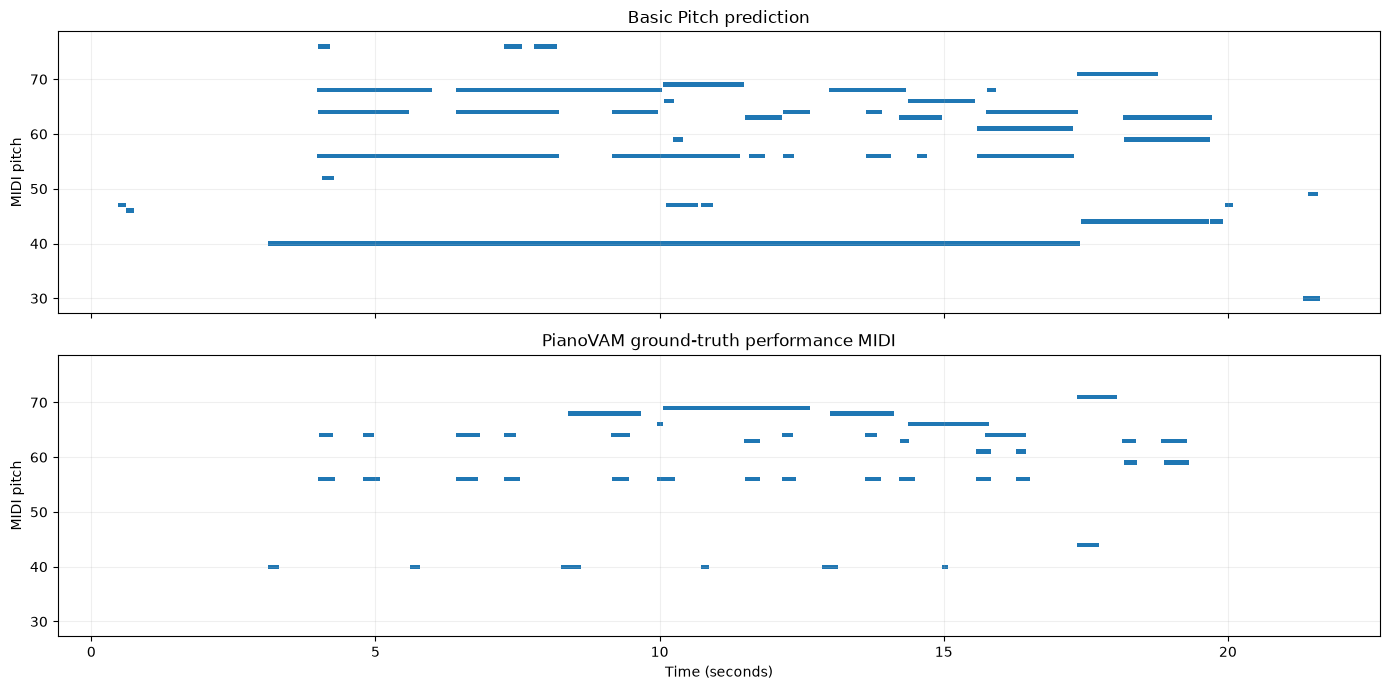

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, sharey=True)

for note in predicted_notes:
    axes[0].broken_barh(
        [(note["onset"], note["duration"])],
        (note["pitch"] - 0.4, 0.8),
    )

for note in ground_truth_notes:
    axes[1].broken_barh(
        [(note["onset"], note["duration"])],
        (note["pitch"] - 0.4, 0.8),
    )

axes[0].set_title("Basic Pitch prediction")
axes[1].set_title("PianoVAM ground-truth performance MIDI")
axes[0].set_ylabel("MIDI pitch")
axes[1].set_ylabel("MIDI pitch")
axes[1].set_xlabel("Time (seconds)")
axes[0].grid(alpha=0.2)
axes[1].grid(alpha=0.2)

plt.tight_layout()

# Batch evaluation using PianoVAM

use the pretrained Basic Pitch as baseline

## AMT Evaluation

precision / recall / F1

visualisation - piano roll

qualitative case study - real recordings of student practice

effectness on feedback brought by AMT (if any), i.e. investigate how transcription uncertainty affects feedback quality
- e.g. if AMT makes a mistake when recgonizing certain note, it will cause an error in the evaluation